# Librerías

In [1]:
# Sistema
import sys
import json
from pathlib import Path

# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import plotly
import plotly.express as px
import plotly.graph_objects as go

# Interactividad en notebook
import ipywidgets as widgets
from IPython.display import display, clear_output

# Configuración pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# Revisión de versiones
print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("plotly:", plotly.__version__)
print("ipywidgets:", widgets.__version__)

Python: 3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]
pandas: 2.3.3
numpy: 2.2.6
plotly: 6.6.0
ipywidgets: 8.1.8


# Lectura

In [2]:
data_path = Path("data")

for file in data_path.glob("*.csv"):
    print(file.name)

train_default.csv
train_PAY_AMT1.csv
val_PAY_AMT1.csv
val_default.csv


In [3]:
train_pay = pd.read_csv(data_path / "train_PAY_AMT1.csv", delimiter='|')
val_pay = pd.read_csv(data_path / "val_PAY_AMT1.csv", delimiter='|')

train_default = pd.read_csv(data_path / "train_default.csv", delimiter='|')
val_default = pd.read_csv(data_path / "val_default.csv", delimiter='|')

In [4]:
print(train_pay.shape)
print(val_pay.shape)
print(train_pay.columns, end='\n\n')

print(train_default.shape)
print(val_default.shape)
print(train_default.columns)

(11250, 23)
(3750, 22)
Index(['ACCOUNT_ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'],
      dtype='object')

(5625, 25)
(1875, 24)
Index(['ACCOUNT_ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
       'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1',
       'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
       'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')


# Clases / Funciones Auxiliares

## EDA

In [5]:
class eda_class:
    """
    Clase para análisis exploratorio visual usando Plotly.

    Permite analizar variables continuas, discretas y relaciones entre variables,
    tomando como base un dataframe principal y un dataframe resumen de campos
    con la columna 'clasificacion'.
    """

    def __init__(
        self,
        df,
        resumen_campos,
        target=None,
        id_col=None,
        output_dir="img"
    ):
        self.df = df.copy()
        self.resumen_campos = resumen_campos.copy()
        self.target = target
        self.id_col = id_col
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)

        self._validar_resumen_campos()

    def _validar_resumen_campos(self):
        """
        Valida que el dataframe resumen tenga las columnas mínimas necesarias.
        """

        columnas_requeridas = {"campo", "clasificacion"}

        columnas_faltantes = columnas_requeridas - set(self.resumen_campos.columns)

        if columnas_faltantes:
            raise ValueError(
                f"Faltan columnas en resumen_campos: {columnas_faltantes}"
            )

    def obtener_columnas(self, clasificacion):
        """
        Obtiene columnas según su clasificación: id, target, continua o discreta.
        """

        columnas = (
            self.resumen_campos
            .loc[self.resumen_campos["clasificacion"] == clasificacion, "campo"]
            .tolist()
        )

        columnas = [col for col in columnas if col in self.df.columns]

        return columnas

    def resumen_continuas(self):
        """
        Genera resumen estadístico para variables continuas.
        """

        continuas = self.obtener_columnas("continua")

        if len(continuas) == 0:
            print("No se encontraron variables continuas.")
            return pd.DataFrame()

        resumen = self.df[continuas].describe(
            percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
        ).T

        return resumen

    def resumen_categoricas(self):
        """
        Genera una tabla de frecuencia y porcentaje para variables discretas.
        """

        discretas = self.obtener_columnas("discreta")

        if len(discretas) == 0:
            print("No se encontraron variables discretas.")
            return pd.DataFrame()

        tablas = []

        for col in discretas:
            tmp = (
                self.df[col]
                .value_counts(dropna=False)
                .reset_index()
            )

            tmp.columns = ["categoria", "frecuencia"]
            tmp["variable"] = col
            tmp["porcentaje"] = tmp["frecuencia"] / len(self.df) * 100
            tmp["porcentaje"] = tmp["porcentaje"].round(2)

            tmp = tmp[["variable", "categoria", "frecuencia", "porcentaje"]]
            tablas.append(tmp)

        return pd.concat(tablas, ignore_index=True)

    def tabla_percentiles(self, col):
        """
        Genera tabla de percentiles para una variable continua.
        """

        self._validar_columna(col)

        percentiles = [0, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1]

        tabla = (
            self.df[col]
            .quantile(percentiles)
            .reset_index()
        )

        tabla.columns = ["percentil", "valor"]
        tabla["percentil"] = (tabla["percentil"] * 100).round(0).astype(int)

        return tabla

    def plot_histograma(self, col, bins=50):
        """
        Genera histograma para una variable continua.
        """

        self._validar_columna(col)

        fig = px.histogram(
            self.df,
            x=col,
            nbins=bins,
            title=f"Histograma de {col}",
            marginal="box"
        )

        fig.update_layout(
            xaxis_title=col,
            yaxis_title="Frecuencia",
            template="plotly_white"
        )

        return fig

    def plot_histograma_log(self, col, bins=50):
        """
        Genera histograma con transformación log1p para una variable continua.
        """

        self._validar_columna(col)

        df_tmp = self.df[[col]].copy()
        df_tmp[f"log1p_{col}"] = np.log1p(df_tmp[col].clip(lower=0))

        fig = px.histogram(
            df_tmp,
            x=f"log1p_{col}",
            nbins=bins,
            title=f"Histograma log1p de {col}",
            marginal="box"
        )

        fig.update_layout(
            xaxis_title=f"log1p({col})",
            yaxis_title="Frecuencia",
            template="plotly_white"
        )

        return fig

    def plot_histograma_porcentaje(self, col, bins=50):
        """
        Genera histograma con eje Y expresado en porcentaje.
        No transforma la variable.
        """
    
        self._validar_columna(col)
    
        fig = px.histogram(
            self.df,
            x=col,
            nbins=bins,
            histnorm="percent",
            title=f"Histograma porcentual de {col}",
            marginal="box"
        )
    
        fig.update_layout(
            xaxis_title=col,
            yaxis_title="Porcentaje",
            template="plotly_white"
        )
    
        return fig

    def plot_histograma_normalizado(self, col, bins=50):
        """
        Genera histograma de una variable continua normalizada mediante z-score.
    
        Normalización:
            z = (x - media) / desviación estándar
        """
    
        self._validar_columna(col)
    
        df_tmp = self.df[[col]].copy()
    
        media = df_tmp[col].mean()
        desviacion = df_tmp[col].std()
    
        if desviacion == 0:
            raise ValueError(f"La columna '{col}' tiene desviación estándar cero y no puede normalizarse.")
    
        col_norm = f"{col}_normalizado"
    
        df_tmp[col_norm] = (df_tmp[col] - media) / desviacion
    
        fig = px.histogram(
            df_tmp,
            x=col_norm,
            nbins=bins,
            title=f"Histograma normalizado de {col}",
            marginal="box"
        )
    
        fig.update_layout(
            xaxis_title=f"{col} normalizado: (x - media) / desviación estándar",
            yaxis_title="Frecuencia",
            template="plotly_white"
        )
    
        return fig

    def plot_boxplot(self, col):
        """
        Genera boxplot para una variable continua.
        """

        self._validar_columna(col)

        fig = px.box(
            self.df,
            y=col,
            points="outliers",
            title=f"Boxplot de {col}"
        )

        fig.update_layout(
            yaxis_title=col,
            template="plotly_white"
        )

        return fig

    def plot_barras_cat_pct(self, col):
        """
        Genera gráfico de barras porcentual para una variable discreta.
        """

        self._validar_columna(col)

        tabla = (
            self.df[col]
            .value_counts(dropna=False, normalize=True)
            .mul(100)
            .reset_index()
        )

        tabla.columns = [col, "porcentaje"]
        tabla["porcentaje"] = tabla["porcentaje"].round(2)
        tabla[col] = tabla[col].astype(str)

        fig = px.bar(
            tabla,
            x=col,
            y="porcentaje",
            text="porcentaje",
            title=f"Distribución porcentual de {col}"
        )

        fig.update_traces(
            texttemplate="%{text:.2f}%",
            textposition="outside"
        )

        fig.update_layout(
            xaxis_title=col,
            yaxis_title="Porcentaje",
            template="plotly_white"
        )

        return fig

    def plot_scatter(self, x_col, y_col):
        """
        Genera gráfico de dispersión entre dos variables continuas.
        """

        self._validar_columna(x_col)
        self._validar_columna(y_col)

        fig = px.scatter(
            self.df,
            x=x_col,
            y=y_col,
            title=f"Dispersión: {x_col} vs {y_col}",
            opacity=0.7,
            trendline="ols"
        )

        fig.update_layout(
            xaxis_title=x_col,
            yaxis_title=y_col,
            template="plotly_white"
        )

        return fig

    def guardar_figura(self, fig, nombre, formato="html"):
        """
        Guarda una figura de Plotly en la carpeta de salida.

        Por defecto guarda en formato HTML para mantener interactividad.
        """

        nombre_limpio = self._limpiar_nombre_archivo(nombre)

        if formato != "html":
            raise ValueError("Por ahora solo se permite guardar en formato html.")

        output_path = self.output_dir / f"{nombre_limpio}.html"

        fig.write_html(
            output_path,
            include_plotlyjs="cdn",
            full_html=True
        )

        print(f"Gráfico guardado en: {output_path}")

        return output_path

    def _validar_columna(self, col):
        """
        Valida que una columna exista en el dataframe.
        """

        if col not in self.df.columns:
            raise ValueError(f"La columna '{col}' no existe en el dataframe.")

    def _limpiar_nombre_archivo(self, nombre):
        """
        Limpia el nombre del archivo para evitar caracteres problemáticos.
        """

        nombre = str(nombre)
        nombre = nombre.replace(" ", "_")
        nombre = nombre.replace("/", "_")
        nombre = nombre.replace("\\", "_")
        nombre = nombre.replace(":", "_")
        nombre = nombre.replace(".", "_")

        return nombre

    def detectar_outliers_iqr(self, cols=None, factor=1.5):
        """
        Detecta outliers usando la regla del rango intercuartílico.
    
        Parameters
        ----------
        cols : list or None
            Columnas continuas a evaluar. Si es None, usa las clasificadas como continuas.
        factor : float
            Multiplicador del IQR. Usualmente 1.5 para outliers moderados y 3.0 para extremos.
    
        Returns
        -------
        pandas.DataFrame
            Resumen de outliers por variable.
        """
    
        if cols is None:
            cols = self.obtener_columnas("continua")
    
        resultados = []
    
        for col in cols:
            q1 = self.df[col].quantile(0.25)
            q3 = self.df[col].quantile(0.75)
            iqr = q3 - q1
    
            limite_inf = q1 - factor * iqr
            limite_sup = q3 + factor * iqr
    
            mask_outlier = (self.df[col] < limite_inf) | (self.df[col] > limite_sup)
    
            resultados.append({
                "variable": col,
                "q1": q1,
                "q3": q3,
                "iqr": iqr,
                "limite_inferior": limite_inf,
                "limite_superior": limite_sup,
                "n_outliers": mask_outlier.sum(),
                "pct_outliers": mask_outlier.mean() * 100
            })
    
        return pd.DataFrame(resultados).sort_values("pct_outliers", ascending=False)

    def resumen_percentiles_extremos(self, cols=None):
        """
        Calcula percentiles extremos para variables continuas.
        """
    
        if cols is None:
            cols = self.obtener_columnas("continua")
    
        percentiles = [0, 0.001, 0.005, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.995, 0.999, 1]
    
        resumen = (
            self.df[cols]
            .quantile(percentiles)
            .T
        )
    
        resumen.columns = [
            f"p{int(p * 1000) / 10}" if p not in [0, 1] else ("min" if p == 0 else "max")
            for p in percentiles
        ]
    
        return resumen

    def detectar_outliers_modified_zscore(self, cols=None, umbral=3.5):
        """
        Detecta outliers usando modified z-score basado en mediana y MAD.
        """
    
        if cols is None:
            cols = self.obtener_columnas("continua")
    
        resultados = []
    
        for col in cols:
            mediana = self.df[col].median()
            mad = np.median(np.abs(self.df[col] - mediana))
    
            if mad == 0:
                continue
    
            modified_z = 0.6745 * (self.df[col] - mediana) / mad
            mask_outlier = np.abs(modified_z) > umbral
    
            resultados.append({
                "variable": col,
                "mediana": mediana,
                "mad": mad,
                "umbral": umbral,
                "n_outliers": mask_outlier.sum(),
                "pct_outliers": mask_outlier.mean() * 100
            })
    
        return pd.DataFrame(resultados).sort_values("pct_outliers", ascending=False)

    def detectar_outliers_isolation_forest(self, cols=None, contamination=0.01, random_state=42):
        """
        Detecta outliers multivariados usando Isolation Forest.
        """
    
        if cols is None:
            cols = self.obtener_columnas("continua")
    
        X = self.df[cols].copy()
    
        scaler = RobustScaler()
        X_scaled = scaler.fit_transform(X)
    
        iso = IsolationForest(
            contamination=contamination,
            random_state=random_state
        )
    
        pred = iso.fit_predict(X_scaled)
    
        resultado = self.df[[self.id_col]].copy() if self.id_col in self.df.columns else pd.DataFrame(index=self.df.index)
        resultado["outlier_isolation_forest"] = pred
        resultado["es_outlier"] = resultado["outlier_isolation_forest"] == -1
    
        return resultado

## Dashboard

In [6]:
import ipywidgets as widgets
from IPython.display import display, clear_output

class eda_dashboard_class:
    """
    Dashboard interactivo independiente para EDA en Jupyter Notebooks.
    Funciona mediante composición recibiendo una instancia de eda_class.
    Mantiene la estabilidad controlando la visibilidad de los paneles de control.
    """

    def __init__(self, eda):
        # 1. Almacenar la instancia de eda_class (Composición)
        self.eda = eda
        
        # Estado interno para el guardado de archivos
        self.fig_actual = None
        self.nombre_actual = None

        # Obtener listas de columnas disponibles desde eda_class
        self.continuas = self.eda.obtener_columnas("continua")
        self.discretas = self.eda.obtener_columnas("discreta")

        # 2. Definición de las áreas de salida (Outputs)
        self.plot_output = widgets.Output(
            layout=widgets.Layout(
                width="100%",
                min_height="540px",
                border="1px solid #ddd",
                padding="10px"
            )
        )

        self.msg_output = widgets.Output(
            layout=widgets.Layout(
                width="100%",
                min_height="40px"
            )
        )

        # 3. Construcción de la interfaz
        self._crear_widgets()
        self._crear_paneles()
        self._configurar_eventos()

    def _crear_widgets(self):
        """Inicializa todos los controles requeridos una sola vez."""
        
        # Selector de Tipo de Análisis (ToggleButtons cumple con no ser dropdown)
        self.tipo_analisis = widgets.ToggleButtons(
            options=["Continua", "Discreta", "Continua vs continua"],
            value="Continua",
            description="Análisis:",
            layout=widgets.Layout(width="100%")
        )

        # --- Controles para Variables Continuas ---
        #self.grafico_continua = widgets.Select(
        #    options=["Histograma", "Histograma log", "Histograma normalizado", "Boxplot", "Tabla percentiles"],
        #    value="Histograma",
        #    description="Gráfico:",
        #    rows=5,
        #    layout=widgets.Layout(width="100%")
        #)

        self.grafico_continua = widgets.Select(
            options=[
                "Histograma",
                "Histograma log",
                "Histograma porcentual",
                "Histograma normalizado",
                "Boxplot",
                "Tabla percentiles"
            ],
            value="Histograma",
            description="Gráfico:",
            rows=6,
            layout=widgets.Layout(width="100%")
        )

        self.variable_continua = widgets.Select(
            options=self.continuas,
            value=self.continuas[0] if self.continuas else None,
            description="Variable:",
            rows=8,
            layout=widgets.Layout(width="100%")
        )

        self.bins = widgets.IntSlider(
            value=50,
            min=10,
            max=100,
            step=5,
            description="Bins:",
            continuous_update=False, # Evita actualizaciones ruidosas mientras se arrastra
            layout=widgets.Layout(width="100%")
        )

        # --- Controles para Variables Discretas ---
        self.grafico_discreta = widgets.Select(
            options=["Barras porcentuales", "Tabla frecuencias"],
            value="Barras porcentuales",
            description="Gráfico:",
            rows=2,
            layout=widgets.Layout(width="100%")
        )

        self.variable_discreta = widgets.Select(
            options=self.discretas,
            value=self.discretas[0] if self.discretas else None,
            description="Variable:",
            rows=8,
            layout=widgets.Layout(width="100%")
        )

        # --- Controles para Análisis Bivariado (Scatter) ---
        self.variable_x = widgets.Select(
            options=self.continuas,
            value=self.continuas[0] if self.continuas else None,
            description="Eje X:",
            rows=6,
            layout=widgets.Layout(width="100%")
        )

        self.variable_y = widgets.Select(
            options=self.continuas,
            value=self.continuas[1] if len(self.continuas) > 1 else (self.continuas[0] if self.continuas else None),
            description="Eje Y:",
            rows=6,
            layout=widgets.Layout(width="100%")
        )

        # --- Botón de Acción Permanente ---
        self.boton_guardar = widgets.Button(
            description="Guardar HTML",
            button_style="success", 
            icon="save",
            layout=widgets.Layout(width="100%", margin="10px 0px 0px 0px")
        )

    def _crear_paneles(self):
        """Encapsula los widgets en contenedores lógicos y define el Layout General."""
        
        # Sub-paneles dinámicos
        self.panel_continuas = widgets.VBox([
            self.grafico_continua,
            self.variable_continua,
            self.bins
        ], layout=widgets.Layout(width="100%"))

        self.panel_discretas = widgets.VBox([
            self.grafico_discreta,
            self.variable_discreta
        ], layout=widgets.Layout(width="100%"))

        self.panel_scatter = widgets.VBox([
            widgets.HTML("<b>Variable X (Continua)</b>"),
            self.variable_x,
            widgets.HTML("<b style='margin-top:5px; display:block;'>Variable Y (Continua)</b>"),
            self.variable_y
        ], layout=widgets.Layout(width="100%"))

        # Panel de control Izquierdo unificado
        self.panel_control = widgets.VBox(
            [
                widgets.HTML("<h2 style='margin:0 0 10px 0; color:#2c3e50;'>Panel EDA</h2>"),
                self.tipo_analisis,
                widgets.HTML("<hr style='margin:10px 0;'>"),
                self.panel_continuas,
                self.panel_discretas,
                self.panel_scatter,
                widgets.HTML("<hr style='margin:10px 0;'>"),
                self.boton_guardar,
                self.msg_output
            ],
            layout=widgets.Layout(
                width="350px",
                border="1px solid #ccc",
                padding="15px",
                border_radius="4px",
                background_color="#fdfdfd"
            )
        )

        # Inicializar la visibilidad por defecto
        self._actualizar_visibilidad_paneles()

    def _configurar_eventos(self):
        """Asigna los observadores reactivos a cada widget."""
        
        # Cambio en la categoría principal de análisis
        self.tipo_analisis.observe(self._evento_cambio_tipo, names="value")

        # Observadores de cambio de valor para actualización automática del gráfico
        widgets_reactivos = [
            self.grafico_continua,
            self.grafico_discreta,
            self.variable_continua,
            self.variable_discreta,
            self.variable_x,
            self.variable_y,
            self.bins
        ]
        for widget in widgets_reactivos:
            widget.observe(self._evento_cambio_opcion, names="value")

        # Evento del botón de guardado
        self.boton_guardar.on_click(self._guardar_grafico)

    def _evento_cambio_tipo(self, change):
        """Maneja el cambio de tipo de análisis modificando propiedades CSS de visualización."""
        self._actualizar_visibilidad_paneles()
        self._actualizar_grafico()

    def _evento_cambio_opcion(self, change):
        """Callback directo para cualquier cambio en los selectores de variables o gráficos."""
        self._actualizar_grafico()

    def _actualizar_visibilidad_paneles(self):
        """Oculta o muestra sub-paneles usando CSS flex/none para preservar instancias de widgets."""
        tipo = self.tipo_analisis.value

        self.panel_continuas.layout.display = "none"
        self.panel_discretas.layout.display = "none"
        self.panel_scatter.layout.display = "none"
        self.bins.layout.display = "none" # Slider exclusivo de histogramas

        if tipo == "Continua":
            self.panel_continuas.layout.display = "flex"
            if "Histograma" in self.grafico_continua.value:
                self.bins.layout.display = "flex"
                
        elif tipo == "Discreta":
            self.panel_discretas.layout.display = "flex"
            
        elif tipo == "Continua vs continua":
            self.panel_scatter.layout.display = "flex"

    def _actualizar_grafico(self):
        """Limpia el output actual, evalúa las selecciones y renderiza el nuevo componente."""
        tipo = self.tipo_analisis.value
        
        # Forzar ocultamiento del slider dinámicamente si cambia el tipo de gráfico continuo
        if tipo == "Continua":
            self.bins.layout.display = "flex" if "Histograma" in self.grafico_continua.value else "none"

        # Limpieza reactiva del contenedor del gráfico
        self.plot_output.clear_output(wait=True)

        with self.plot_output:
            try:
                if tipo == "Continua":
                    self._procesar_analisis_continuo()
                elif tipo == "Discreta":
                    self._procesar_analisis_discreto()
                elif tipo == "Continua vs continua":
                    self._procesar_analisis_scatter()
            except Exception as e:
                self.fig_actual = None
                self.nombre_actual = None
                print(f"Error al generar la visualización: {str(e)}")

    def _procesar_analisis_continuo(self):
        col = self.variable_continua.value
        grafico = self.grafico_continua.value
        nbins = self.bins.value
    
        if not col:
            print("No hay variables continuas disponibles.")
            return
    
        if grafico == "Histograma":
            fig = self.eda.plot_histograma(col, bins=nbins)
            self._preparar_render(fig, f"hist_{col}")
    
        elif grafico == "Histograma log":
            fig = self.eda.plot_histograma_log(col, bins=nbins)
            self._preparar_render(fig, f"hist_log_{col}")
    
        elif grafico == "Histograma porcentual":
            fig = self.eda.plot_histograma_porcentaje(col, bins=nbins)
            self._preparar_render(fig, f"hist_pct_{col}")
    
        elif grafico == "Histograma normalizado":
            fig = self.eda.plot_histograma_normalizado(col, bins=nbins)
            self._preparar_render(fig, f"hist_norm_{col}")
    
        elif grafico == "Boxplot":
            fig = self.eda.plot_boxplot(col)
            self._preparar_render(fig, f"box_{col}")
    
        elif grafico == "Tabla percentiles":
            self.fig_actual = None
            self.nombre_actual = None
    
            tabla = self.eda.tabla_percentiles(col)
            display(tabla)
    
            self._mostrar_mensaje(f"Tabla de percentiles cargada para: {col}")

    def _procesar_analisis_discreto(self):
        col = self.variable_discreta.value
        grafico = self.grafico_discreta.value

        if not col:
            print("No hay variables discretas disponibles.")
            return

        if grafico == "Barras porcentuales":
            fig = self.eda.plot_barras_cat_pct(col)
            self._preparar_render(fig, f"bar_pct_{col}")
        elif grafico == "Tabla frecuencias":
            self.fig_actual = None
            self.nombre_actual = None
            # Filtrar el resumen general de categóricas para la variable seleccionada
            df_cat = self.eda.resumen_categoricas()
            if not df_cat.empty and "variable" in df_cat.columns:
                tabla = df_cat[df_cat["variable"] == col].reset_index(drop=True)
                display(tabla)
                self._mostrar_mensaje(f"Tabla de frecuencias cargada para: {col}")
            else:
                print("No se pudieron extraer datos de resumen_categoricas().")

    def _procesar_analisis_scatter(self):
        x = self.variable_x.value
        y = self.variable_y.value

        if not x or not y:
            print("Se requieren dos variables continuas para generar la dispersión.")
            return

        fig = self.eda.plot_scatter(x, y)
        self._preparar_render(fig, f"scatter_{x}_vs_{y}")

    def _preparar_render(self, fig, nombre_archivo):
        """Aplica dimensiones estables a las figuras Plotly y las despliega en el Output."""
        fig.update_layout(
            width=850,
            height=500,
            margin=dict(l=50, r=30, t=60, b=50)
        )
        self.fig_actual = fig
        self.nombre_actual = nombre_archivo
        
        display(fig)
        self._mostrar_mensaje(f"Gráfico interactivo listo: {nombre_archivo}")

    def _guardar_grafico(self, button):
        """Manejador del evento click del botón verde de guardado."""
        if self.fig_actual is None or self.nombre_actual is None:
            self._mostrar_mensaje("⚠️ No hay gráfico para guardar. Las tablas no se guardan con este botón.")
            return

        try:
            # Invocar al método del objeto inyectado eda_class
            path_guardado = self.eda.guardar_figura(
                fig=self.fig_actual,
                nombre=self.nombre_actual,
                formato="html"
            )
            self._mostrar_mensaje(f"💾 Guardado con éxito en:\n{path_guardado}")
        except Exception as e:
            self._mostrar_mensaje(f"❌ Error al guardar el archivo: {str(e)}")

    def _mostrar_mensaje(self, texto):
        """Actualiza la sección informativa inferior del panel de control."""
        self.msg_output.clear_output(wait=True)
        with self.msg_output:
            print(texto)

    def mostrar(self):
        """Renderiza la estructura completa del Dashboard (Control Izquierdo + Gráficos Derecho)."""
        interfaz_completa = widgets.HBox(
            [self.panel_control, self.plot_output],
            layout=widgets.Layout(
                width="100%",
                align_items="flex-start"
            )
        )
        display(interfaz_completa)
        
        # Inicialización del primer gráfico tras el despliegue de componentes
        self._actualizar_grafico()

# Modelo de Regresión

In [7]:
train_pay.head()

,ACCOUNT_ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,17644,"350,000.00",2,1,1,59,-2,-2,-2,-2,-2,0.00,0.00,0.00,0.00,0.00,"42,800.00",0.00,0.00,0.00,0.00,"42,800.00",0.00
1,18913,"70,000.00",1,3,2,53,0,0,0,0,0,"9,928.00","11,259.00","12,262.00","17,046.00","17,618.00","18,321.00","1,497.00","1,500.00","5,000.00","1,000.00","1,000.00","1,000.00"
2,27173,"130,000.00",2,2,2,23,-1,-2,-2,-2,-2,69.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,17922,"220,000.00",2,1,1,44,2,0,0,0,2,"34,510.00","33,661.00","34,913.00","36,334.00","38,729.00","39,062.00",0.00,"2,100.00","2,000.00","3,000.00","1,100.00","1,700.00"
4,23294,"300,000.00",1,1,1,46,-1,-1,-1,-1,-1,"132,760.00","1,968.00","4,436.00",839.00,"5,792.00","7,053.00","1,977.00","4,458.00",862.00,"5,821.00","7,088.00","9,647.00"


In [12]:
class regresion_class:
    """
    Clase base para el flujo de regresión.

    Permite:
    - leer el diccionario de datos desde un archivo JSON,
    - generar resumen general del dataset,
    - generar resumen por campo,
    - identificar variables discretas y continuas.
    """

    def __init__(
        self,
        target="PAY_AMT1",
        id_col="ACCOUNT_ID",
        dict_path="config/diccionario_datos.json"
    ):
        self.target = target
        self.id_col = id_col
        self.dict_path = Path(dict_path)
        self.diccionario_datos = self.leer_diccionario()

    def leer_diccionario(self):
        """
        Lee el diccionario de datos desde un archivo JSON.
        """

        if not self.dict_path.exists():
            raise FileNotFoundError(
                f"No se encontró el archivo: {self.dict_path}"
            )

        with open(self.dict_path, "r", encoding="utf-8") as file:
            diccionario = json.load(file)

        return diccionario

    def resumen_general(self, df):
        """
        Muestra información general del dataset.
        """

        print("Resumen general del dataset")
        print("-" * 50)
        print(f"Filas: {df.shape[0]:,}")
        print(f"Columnas: {df.shape[1]:,}")
        print(f"Duplicados completos: {df.duplicated().sum():,}")

        if self.id_col in df.columns:
            print(f"{self.id_col} únicos: {df[self.id_col].nunique():,}")
            print(f"{self.id_col} duplicados: {df[self.id_col].duplicated().sum():,}")
        else:
            print(f"No se encontró la columna ID: {self.id_col}")

        if self.target in df.columns:
            print(f"Variable objetivo: {self.target}")
        else:
            print("Este dataset no contiene la variable objetivo.")

    def resumen_campos(self, df):
        """
        Genera un dataframe resumen con información por columna.
        Incluye descripción, porcentaje de nulos, tipo de dato,
        valores únicos y clasificación del campo.
        """
    
        tipos_variables = self.identificar_tipos_variables(df)
    
        def clasificar_campo(col):
            if col == tipos_variables["id"]:
                return "id"
            elif col == tipos_variables["target"]:
                return "target"
            elif col in tipos_variables["discretas"]:
                return "discreta"
            elif col in tipos_variables["continuas"]:
                return "continua"
            else:
                return "no clasificada"
    
        resumen = pd.DataFrame({
            "campo": df.columns,
            "descripcion": [
                self.diccionario_datos.get(col, "Descripción no disponible.")
                for col in df.columns
            ],
            "clasificacion": [
                clasificar_campo(col)
                for col in df.columns
            ],
            "porcentaje_nulos": [
                df[col].isna().mean() * 100
                for col in df.columns
            ],
            "tipo_dato": [
                str(df[col].dtype)
                for col in df.columns
            ],
            "valores_unicos": [
                df[col].nunique(dropna=True)
                for col in df.columns
            ]
        })
    
        resumen["porcentaje_nulos"] = resumen["porcentaje_nulos"].round(2)
    
        return resumen

    def identificar_tipos_variables(self, df):
        """
        Clasifica columnas en ID, objetivo, discretas y continuas.
        """

        posibles_discretas = [
            "SEX", "EDUCATION", "MARRIAGE",
            "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"
        ]

        discretas = [
            col for col in posibles_discretas
            if col in df.columns
        ]

        excluir = [
            col for col in [self.id_col, self.target]
            if col in df.columns
        ]

        continuas = [
            col for col in df.columns
            if col not in discretas + excluir
        ]

        return {
            "id": self.id_col if self.id_col in df.columns else None,
            "target": self.target if self.target in df.columns else None,
            "discretas": discretas,
            "continuas": continuas
        }

    def validar_columnas_diccionario(self, df):
        """
        Revisa si todas las columnas tienen descripción en el diccionario.
        """

        columnas_sin_descripcion = [
            col for col in df.columns
            if col not in self.diccionario_datos
        ]

        if len(columnas_sin_descripcion) == 0:
            print("Todas las columnas tienen descripción en el diccionario.")
        else:
            print("Columnas sin descripción:")
            print(columnas_sin_descripcion)

        return columnas_sin_descripcion

In [13]:
regresion = regresion_class(
    target="PAY_AMT1",
    id_col="ACCOUNT_ID",
    dict_path="config/diccionario_datos.json"
)

## Validación de duplicados

In [14]:
regresion.resumen_general(train_pay)

Resumen general del dataset
--------------------------------------------------
Filas: 11,250
Columnas: 23
Duplicados completos: 0
ACCOUNT_ID únicos: 11,250
ACCOUNT_ID duplicados: 0
Variable objetivo: PAY_AMT1


## Validación de nulos

In [15]:
df_resumen_train_pay = regresion.resumen_campos(train_pay)

df_resumen_train_pay.style.background_gradient(
    subset=["porcentaje_nulos", "valores_unicos"],
    cmap="Blues"
)

,campo,descripcion,clasificacion,porcentaje_nulos,tipo_dato,valores_unicos
0,ACCOUNT_ID,Identificador único de cada cliente.,id,0.000000,int64,11250
1,LIMIT_BAL,Monto de la línea de crédito otorgada al cliente.,continua,0.000000,float64,74
2,SEX,"Género del cliente: 1 = masculino, 2 = femenino.",discreta,0.000000,int64,2
3,EDUCATION,"Nivel educativo: 1 = preparatoria, 2 = universidad, 3 = secundaria, 4 = otros, 5 = desconocido, 6 = desconocido, 0 = nulo.",discreta,0.000000,int64,7
4,MARRIAGE,"Estado marital: 1 = casado, 2 = soltero, 3 = otros, 0 = nulo.",discreta,0.000000,int64,4
5,AGE,Edad del cliente en años.,continua,0.000000,int64,54
6,PAY_2,Estado de pago en agosto de 2005.,discreta,0.000000,int64,10
7,PAY_3,Estado de pago en julio de 2005.,discreta,0.000000,int64,11
8,PAY_4,Estado de pago en junio de 2005.,discreta,0.000000,int64,10
9,PAY_5,Estado de pago en mayo de 2005.,discreta,0.000000,int64,9


### Resumen inicial del dataset de regresión

El conjunto de entrenamiento para regresión no presenta valores nulos ni duplicados en el identificador `ACCOUNT_ID`.  
La variable `ACCOUNT_ID` se clasifica únicamente como identificador y no será utilizada como predictor.

La variable objetivo del modelo es `PAY_AMT1`, correspondiente al monto pagado en septiembre de 2005.  
Las variables `SEX`, `EDUCATION`, `MARRIAGE` y `PAY_2` a `PAY_6` se consideran discretas, ya que representan categorías codificadas numéricamente.  
El resto de las variables monetarias, junto con `LIMIT_BAL` y `AGE`, se consideran continuas.

Este resumen permite validar la estructura del dataset y definir el tratamiento posterior mediante transformaciones diferenciadas para variables continuas y discretas.

## EDA

In [16]:
eda = eda_class(
    df=train_pay,
    resumen_campos=df_resumen_train_pay,
    target="PAY_AMT1",
    id_col="ACCOUNT_ID",
    output_dir="img"
)

In [17]:
eda.obtener_columnas("continua")

['LIMIT_BAL',
 'AGE',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6']

In [18]:
eda.obtener_columnas("discreta")

['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

In [19]:
eda.resumen_continuas()

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
LIMIT_BAL,"11,250.00","165,865.78","128,604.46","10,000.00","10,000.00","20,000.00","30,000.00","50,000.00","140,000.00","240,000.00","360,000.00","430,000.00","500,000.00","760,000.00"
AGE,"11,250.00",35.49,9.21,21.00,22.00,23.00,25.00,28.00,34.00,41.00,49.00,53.00,60.00,79.00
BILL_AMT1,"11,250.00","50,650.91","72,318.43","-165,580.00",-79.53,0.00,275.90,"3,604.00","22,841.50","66,622.25","138,425.70","196,921.10","347,023.15","630,458.00"
BILL_AMT2,"11,250.00","48,770.94","70,244.12","-69,777.00",-185.61,0.00,0.00,"2,936.25","21,530.00","63,497.00","134,267.20","191,248.30","333,696.11","646,770.00"
BILL_AMT3,"11,250.00","46,524.52","67,695.14","-61,506.00",-156.63,0.00,0.00,"2,655.50","20,188.50","59,722.25","129,671.90","184,303.05","320,443.42","693,131.00"
BILL_AMT4,"11,250.00","42,670.88","63,186.48","-81,334.00",-202.04,0.00,0.00,"2,400.00","19,076.50","53,316.25","118,322.90","172,989.35","299,715.97","565,669.00"
BILL_AMT5,"11,250.00","39,635.47","59,809.07","-37,594.00",-211.12,0.00,0.00,"1,669.75","18,015.50","49,481.00","112,597.30","162,408.30","281,859.72","547,880.00"
BILL_AMT6,"11,250.00","38,295.71","58,490.89","-339,603.00",-407.75,0.00,0.00,"1,259.25","16,980.50","48,836.25","108,572.00","158,988.15","272,392.89","499,100.00"
PAY_AMT2,"11,250.00","5,763.69","21,199.70",0.00,0.00,0.00,0.00,801.50,"2,000.00","5,000.00","10,139.10","18,324.25","69,951.00","1,227,082.00"
PAY_AMT3,"11,250.00","5,185.42","16,745.60",0.00,0.00,0.00,0.00,396.00,"1,842.00","4,400.00","10,000.00","17,464.70","67,107.61","508,229.00"


In [20]:
eda.resumen_categoricas()

,variable,categoria,frecuencia,porcentaje
0,SEX,2,6820,60.62
1,SEX,1,4430,39.38
2,EDUCATION,2,5326,47.34
3,EDUCATION,1,3889,34.57
4,EDUCATION,3,1862,16.55
...,...,...,...,...
58,PAY_6,7,20,0.18
59,PAY_6,4,17,0.15
60,PAY_6,6,8,0.07
61,PAY_6,5,5,0.04


In [21]:
fig = eda.plot_histograma("PAY_AMT1")
fig.show()

In [22]:
eda.guardar_figura(fig, "hist_PAY_AMT1")

Gráfico guardado en: img/hist_PAY_AMT1.html


PosixPath('img/hist_PAY_AMT1.html')

In [23]:
fig = eda.plot_barras_cat_pct("EDUCATION")
fig.show()

In [24]:
eda.guardar_figura(fig, "bar_pct_EDUCATION")

Gráfico guardado en: img/bar_pct_EDUCATION.html


PosixPath('img/bar_pct_EDUCATION.html')

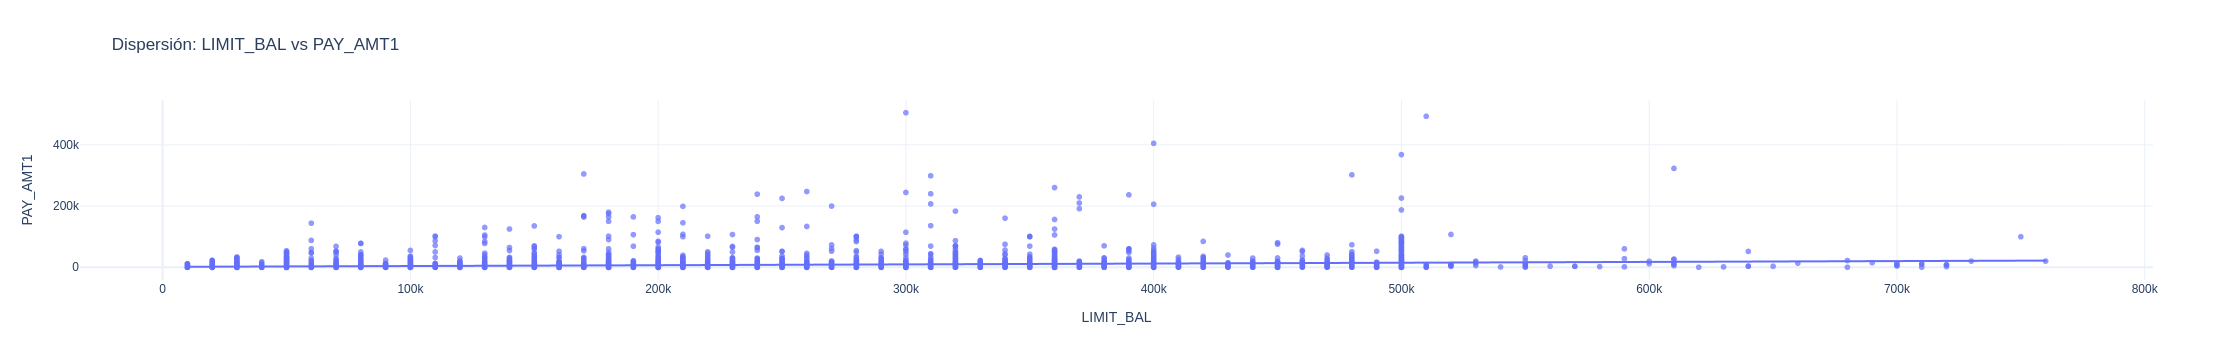

In [26]:
fig = eda.plot_scatter("LIMIT_BAL", "PAY_AMT1")
fig.show()

In [27]:
eda.guardar_figura(fig, "scatter_LIMIT_BAL_vs_PAY_AMT1")

Gráfico guardado en: img/scatter_LIMIT_BAL_vs_PAY_AMT1.html


PosixPath('img/scatter_LIMIT_BAL_vs_PAY_AMT1.html')

In [28]:
dashboard = eda_dashboard_class(eda)
dashboard.mostrar()

## Outliers

In [29]:
eda.detectar_outliers_iqr().sort_values(by='variable')

,variable,q1,q3,iqr,limite_inferior,limite_superior,n_outliers,pct_outliers
1,AGE,28.00,41.00,13.00,8.50,60.50,95,0.84
2,BILL_AMT1,"3,604.00","66,622.25","63,018.25","-90,923.38","161,149.62",873,7.76
3,BILL_AMT2,"2,936.25","63,497.00","60,560.75","-87,904.88","154,338.12",877,7.80
4,BILL_AMT3,"2,655.50","59,722.25","57,066.75","-82,944.62","145,322.38",900,8.00
5,BILL_AMT4,"2,400.00","53,316.25","50,916.25","-73,974.38","129,690.62",1000,8.89
6,BILL_AMT5,"1,669.75","49,481.00","47,811.25","-70,047.12","121,197.88",1007,8.95
7,BILL_AMT6,"1,259.25","48,836.25","47,577.00","-70,106.25","120,201.75",991,8.81
0,LIMIT_BAL,"50,000.00","240,000.00","190,000.00","-235,000.00","525,000.00",51,0.45
8,PAY_AMT2,801.50,"5,000.00","4,198.50","-5,496.25","11,297.75",983,8.74
9,PAY_AMT3,396.00,"4,400.00","4,004.00","-5,610.00","10,406.00",1003,8.92


In [30]:
eda.detectar_outliers_iqr(factor=3.0).sort_values(by='variable')

,variable,q1,q3,iqr,limite_inferior,limite_superior,n_outliers,pct_outliers
1,AGE,28.00,41.00,13.00,-11.00,80.00,0,0.00
2,BILL_AMT1,"3,604.00","66,622.25","63,018.25","-185,450.75","255,677.00",287,2.55
3,BILL_AMT2,"2,936.25","63,497.00","60,560.75","-178,746.00","245,179.25",295,2.62
4,BILL_AMT3,"2,655.50","59,722.25","57,066.75","-168,544.75","230,922.50",317,2.82
5,BILL_AMT4,"2,400.00","53,316.25","50,916.25","-150,348.75","206,065.00",349,3.10
6,BILL_AMT5,"1,669.75","49,481.00","47,811.25","-141,764.00","192,914.75",361,3.21
7,BILL_AMT6,"1,259.25","48,836.25","47,577.00","-141,471.75","191,567.25",343,3.05
0,LIMIT_BAL,"50,000.00","240,000.00","190,000.00","-520,000.00","810,000.00",0,0.00
8,PAY_AMT2,801.50,"5,000.00","4,198.50","-11,794.00","17,595.50",594,5.28
9,PAY_AMT3,396.00,"4,400.00","4,004.00","-11,616.00","16,412.00",597,5.31


In [31]:
eda.detectar_outliers_modified_zscore().sort_values(by='variable')

,variable,mediana,mad,umbral,n_outliers,pct_outliers
1,AGE,34.00,7.00,3.50,4,0.04
2,BILL_AMT1,"22,841.50","22,114.00",3.50,1142,10.15
3,BILL_AMT2,"21,530.00","21,140.00",3.50,1184,10.52
4,BILL_AMT3,"20,188.50","19,828.50",3.50,1214,10.79
5,BILL_AMT4,"19,076.50","18,660.50",3.50,1166,10.36
6,BILL_AMT5,"18,015.50","17,619.50",3.50,1165,10.36
7,BILL_AMT6,"16,980.50","16,664.50",3.50,1209,10.75
0,LIMIT_BAL,"140,000.00","90,000.00",3.50,29,0.26
8,PAY_AMT2,"2,000.00","1,996.00",3.50,888,7.89
9,PAY_AMT3,"1,842.00","1,760.50",3.50,958,8.52


In [32]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler

In [33]:
outliers_if = eda.detectar_outliers_isolation_forest(contamination=0.03)
outliers_if["es_outlier"].mean() * 100

np.float64(3.0044444444444443)

In [34]:
df_sin_outliers_if = eda.df.loc[~outliers_if["es_outlier"]].copy()
df_sin_outliers_if.shape

(10912, 23)

In [35]:
n_original = eda.df.shape[0]
n_filtrado = df_sin_outliers_if.shape[0]
n_eliminados = n_original - n_filtrado
pct_eliminados = n_eliminados / n_original * 100

print("Registros originales:", n_original)
print("Registros sin outliers:", n_filtrado)
print("Outliers eliminados:", n_eliminados)
print("Porcentaje eliminado:", round(pct_eliminados, 2), "%")

Registros originales: 11250
Registros sin outliers: 10912
Outliers eliminados: 338
Porcentaje eliminado: 3.0 %


In [36]:
eda_sin_outliers_if = eda_class(
    df=df_sin_outliers_if,
    resumen_campos=df_resumen_train_pay,
    target="PAY_AMT1",
    id_col="ACCOUNT_ID",
    output_dir="img"
)

In [37]:
eda_sin_outliers_if.detectar_outliers_iqr().sort_values(by='variable')

,variable,q1,q3,iqr,limite_inferior,limite_superior,n_outliers,pct_outliers
1,AGE,28.00,41.00,13.00,8.50,60.50,83,0.76
2,BILL_AMT1,"3,289.00","61,397.25","58,108.25","-83,873.38","148,559.62",768,7.04
3,BILL_AMT2,"2,721.50","58,936.75","56,215.25","-81,601.38","143,259.62",750,6.87
4,BILL_AMT3,"2,448.75","54,623.00","52,174.25","-75,812.62","132,884.38",815,7.47
5,BILL_AMT4,"2,144.75","49,726.75","47,582.00","-69,228.25","121,099.75",834,7.64
6,BILL_AMT5,"1,473.00","46,776.25","45,303.25","-66,481.88","114,731.12",841,7.71
7,BILL_AMT6,"1,104.50","45,840.00","44,735.50","-65,998.75","112,943.25",812,7.44
0,LIMIT_BAL,"50,000.00","230,000.00","180,000.00","-220,000.00","500,000.00",37,0.34
8,PAY_AMT2,747.75,"4,701.50","3,953.75","-5,182.88","10,632.12",826,7.57
9,PAY_AMT3,390.00,"4,000.00","3,610.00","-5,025.00","9,415.00",996,9.13


## Escalado

In [38]:
print(eda_sin_outliers_if.df.columns.tolist())

['ACCOUNT_ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


### Variables continuas

In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline

id_col = "ACCOUNT_ID"
target = "PAY_AMT1"

continuas = eda_sin_outliers_if.obtener_columnas("continua")
discretas = eda_sin_outliers_if.obtener_columnas("discreta")

print("Continuas:")
print(continuas)

print("\nDiscretas:")
print(discretas)

Continuas:
['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

Discretas:
['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']


In [56]:
df_train_clean = eda_sin_outliers_if.df.copy()

X_train_clean = df_train_clean[continuas + discretas].copy()
y_train_clean = df_train_clean[target].copy()

print("X_train_clean:", X_train_clean.shape)
print("y_train_clean:", y_train_clean.shape)

X_train_clean: (10912, 21)
y_train_clean: (10912,)


In [69]:
val_pay.shape

(3750, 22)

In [57]:
preprocessor_scaling = ColumnTransformer(
    transformers=[
        ("continuas_robust", RobustScaler(), continuas),
        ("discretas_passthrough", "passthrough", discretas)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [58]:
X_train_scaled_array = preprocessor_scaling.fit_transform(X_train_clean)

X_train_scaled = pd.DataFrame(
    X_train_scaled_array,
    columns=preprocessor_scaling.get_feature_names_out(),
    index=X_train_clean.index
)

X_train_scaled.head()

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,SEX,EDUCATION,MARRIAGE,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
0,1.22,1.92,-0.37,-0.36,-0.37,-0.39,-0.38,0.60,-0.51,-0.48,-0.40,11.31,-0.37,2.00,1.00,1.00,-2.00,-2.00,-2.00,-2.00,-2.00
1,-0.33,1.46,-0.20,-0.16,-0.14,-0.03,0.01,0.05,-0.13,0.91,-0.12,-0.14,-0.10,1.00,3.00,2.00,0.00,0.00,0.00,0.00,0.00
2,0.00,-0.85,-0.37,-0.36,-0.37,-0.39,-0.38,-0.36,-0.51,-0.48,-0.40,-0.41,-0.37,2.00,2.00,2.00,-1.00,-2.00,-2.00,-2.00,-2.00
3,0.50,0.77,0.23,0.24,0.30,0.38,0.48,0.51,0.03,0.08,0.44,-0.11,0.09,2.00,1.00,1.00,2.00,0.00,0.00,0.00,2.00
4,0.94,0.92,1.92,-0.33,-0.29,-0.37,-0.25,-0.20,0.62,-0.24,1.22,1.53,2.22,1.00,1.00,1.00,-1.00,-1.00,-1.00,-1.00,-1.00


In [59]:
percentiles = np.concatenate([
    np.arange(0.00, 0.06, step=0.01),
    np.arange(0.10, 0.90, step=0.10),
    np.arange(0.95, 1.00, step=0.01)
])

In [60]:
X_train_scaled[continuas].describe(percentiles=percentiles).T

,count,mean,std,min,0%,1%,2%,3%,4%,5%,10%,20%,30%,40%,50%,60%,70%,80%,95%,96%,97%,98%,99%,100%,max
LIMIT_BAL,"10,912.00",0.16,0.68,-0.67,-0.67,-0.67,-0.61,-0.61,-0.61,-0.61,-0.56,-0.44,-0.33,-0.17,0.00,0.22,0.39,0.67,1.50,1.61,1.83,2.06,2.06,3.28,3.28
AGE,"10,912.00",0.11,0.71,-1.00,-1.00,-0.92,-0.92,-0.85,-0.85,-0.85,-0.69,-0.54,-0.38,-0.23,0.00,0.23,0.46,0.69,1.46,1.54,1.62,1.77,1.92,3.15,3.15
BILL_AMT1,"10,912.00",0.40,1.00,-3.22,-3.22,-0.37,-0.37,-0.37,-0.37,-0.37,-0.36,-0.34,-0.27,-0.14,0.00,0.23,0.49,0.97,2.58,2.79,3.06,3.44,3.95,8.35,8.35
BILL_AMT2,"10,912.00",0.40,0.99,-1.60,-1.60,-0.37,-0.36,-0.36,-0.36,-0.36,-0.36,-0.34,-0.27,-0.14,0.00,0.21,0.51,0.95,2.60,2.82,3.08,3.43,3.92,8.76,8.76
BILL_AMT3,"10,912.00",0.40,1.01,-1.55,-1.55,-0.38,-0.37,-0.37,-0.37,-0.37,-0.37,-0.35,-0.28,-0.15,0.00,0.20,0.53,0.96,2.60,2.88,3.16,3.50,4.01,8.30,8.30
BILL_AMT4,"10,912.00",0.38,1.02,-1.76,-1.76,-0.39,-0.39,-0.39,-0.39,-0.39,-0.39,-0.37,-0.30,-0.17,0.00,0.19,0.48,0.94,2.67,2.91,3.25,3.60,4.13,7.38,7.38
BILL_AMT5,"10,912.00",0.37,1.02,-1.21,-1.21,-0.38,-0.38,-0.38,-0.38,-0.38,-0.38,-0.37,-0.31,-0.18,0.00,0.16,0.43,0.88,2.69,2.89,3.26,3.62,4.10,7.97,7.97
BILL_AMT6,"10,912.00",0.38,1.02,-7.95,-7.95,-0.37,-0.36,-0.36,-0.36,-0.36,-0.36,-0.35,-0.30,-0.18,0.00,0.16,0.42,0.88,2.70,2.92,3.24,3.66,4.07,6.29,6.29
PAY_AMT2,"10,912.00",0.65,2.76,-0.51,-0.51,-0.51,-0.51,-0.51,-0.51,-0.51,-0.51,-0.46,-0.23,-0.12,0.00,0.21,0.49,0.85,3.30,4.21,4.86,7.11,12.12,59.60,59.60
PAY_AMT3,"10,912.00",0.70,3.06,-0.48,-0.48,-0.48,-0.48,-0.48,-0.48,-0.48,-0.48,-0.48,-0.27,-0.14,0.00,0.16,0.41,0.91,3.68,4.64,5.67,7.83,13.35,102.49,102.49


In [61]:
X_val_reg = val_pay[continuas + discretas].copy()

X_val_scaled_array = preprocessor_scaling.transform(X_val_reg)

X_val_scaled = pd.DataFrame(
    X_val_scaled_array,
    columns=preprocessor_scaling.get_feature_names_out(),
    index=val_pay.index
)

X_val_scaled.head()

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,SEX,EDUCATION,MARRIAGE,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
0,-0.67,0.69,-0.22,-0.19,-0.16,-0.16,-0.15,-0.13,0.00,-0.48,-0.40,-0.41,-0.28,1.00,2.00,1.00,2.00,2.00,4.00,3.00,2.00
1,0.89,0.46,4.08,4.33,4.71,5.17,4.50,4.54,2.02,2.26,1.75,1.73,2.32,2.00,2.00,2.00,0.00,0.00,0.00,0.00,0.00
2,-0.28,0.15,1.00,1.05,1.16,1.26,0.64,0.66,0.15,-0.37,0.13,0.08,0.11,1.00,2.00,2.00,0.00,2.00,2.00,0.00,0.00
3,-0.56,0.31,-0.23,-0.20,-0.18,-0.16,-0.15,-0.16,-0.15,-0.27,-0.40,-0.14,0.44,2.00,2.00,1.00,0.00,0.00,0.00,2.00,0.00
4,-0.06,-0.62,1.15,1.12,1.13,1.25,1.37,0.89,0.53,0.36,0.44,0.14,-0.37,1.00,3.00,2.00,0.00,0.00,0.00,0.00,0.00


In [62]:
val_ids_reg = val_pay[id_col].copy()

val_ids_reg.head()

0    5336
1    5678
2    7675
3    3985
4    4657
Name: ACCOUNT_ID, dtype: int64

In [63]:
print("Train original sin outliers:", df_train_clean.shape)
print("X_train_scaled:", X_train_scaled.shape)
print("y_train_clean:", y_train_clean.shape)

print("\nValidación original:", val_pay.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("IDs validación:", val_ids_reg.shape)

Train original sin outliers: (10912, 23)
X_train_scaled: (10912, 21)
y_train_clean: (10912,)

Validación original: (3750, 22)
X_val_scaled: (3750, 21)
IDs validación: (3750,)


### Embeddings

In [64]:
X_cont_train = X_train_scaled[continuas].copy()
X_cat_train = X_train_scaled[discretas].copy()

X_cont_val = X_val_scaled[continuas].copy()
X_cat_val = X_val_scaled[discretas].copy()

In [65]:
from sklearn.preprocessing import OrdinalEncoder
import tensorflow as tf
from tensorflow.keras import layers, Model

In [66]:
continuas = eda_sin_outliers_if.obtener_columnas("continua")
discretas = eda_sin_outliers_if.obtener_columnas("discreta")

target = "PAY_AMT1"
id_col = "ACCOUNT_ID"

print("Continuas:", continuas)
print("Discretas:", discretas)

Continuas: ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Discretas: ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']


In [67]:
df_train_clean = eda_sin_outliers_if.df.copy()

X_train_raw = df_train_clean[continuas + discretas].copy()
y_train = df_train_clean[target].copy()

X_val_raw = val_pay[continuas + discretas].copy()
val_ids = val_pay[id_col].copy()

In [70]:
encoder_cat = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_cat_train_encoded = encoder_cat.fit_transform(X_train_raw[discretas])
X_cat_val_encoded = encoder_cat.transform(X_val_raw[discretas])

# Sumamos 1 para reservar 0 como categoría desconocida
X_cat_train_encoded = X_cat_train_encoded.astype("int32") + 1
X_cat_val_encoded = X_cat_val_encoded.astype("int32") + 1

In [71]:
pd.DataFrame(
    X_cat_train_encoded,
    columns=discretas,
    index=X_train_raw.index
).head()

,SEX,EDUCATION,MARRIAGE,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
0,2,2,2,1,1,1,1,1
1,1,4,3,3,3,3,3,3
2,2,3,3,2,1,1,1,1
3,2,2,2,5,3,3,3,4
4,1,2,2,2,2,2,2,2


In [72]:
X_cont_train = X_train_scaled[continuas].astype("float32").values
X_cont_val = X_val_scaled[continuas].astype("float32").values

X_cat_train = {
    col: X_cat_train_encoded[:, i].astype("int32")
    for i, col in enumerate(discretas)
}

X_cat_val = {
    col: X_cat_val_encoded[:, i].astype("int32")
    for i, col in enumerate(discretas)
}

y_train_array = y_train.astype("float32").values

In [76]:
cardinalidades = {}

for i, col in enumerate(discretas):
    n_categorias = len(encoder_cat.categories_[i])
    cardinalidades[col] = n_categorias + 1  # +1 por categoría desconocida 0

cardinalidades

{'SEX': 3,
 'EDUCATION': 8,
 'MARRIAGE': 5,
 'PAY_2': 11,
 'PAY_3': 12,
 'PAY_4': 11,
 'PAY_5': 10,
 'PAY_6': 11}

In [77]:
def crear_modelo_regresion_embeddings(
    n_continuas,
    cardinalidades,
    embedding_dim_default=4
):
    """
    Crea una red neuronal tabular para regresión usando:
    - variables continuas escaladas,
    - embeddings para variables discretas.
    """

    # Entrada de variables continuas
    input_cont = layers.Input(
        shape=(n_continuas,),
        name="continuas"
    )

    inputs = [input_cont]
    embeddings = []

    # Entradas y embeddings para variables discretas
    for col, cardinalidad in cardinalidades.items():

        input_cat = layers.Input(
            shape=(1,),
            name=col
        )

        emb_dim = min(embedding_dim_default, max(2, cardinalidad // 2))

        emb = layers.Embedding(
            input_dim=cardinalidad,
            output_dim=emb_dim,
            name=f"emb_{col}"
        )(input_cat)

        emb = layers.Flatten(name=f"flat_{col}")(emb)

        inputs.append(input_cat)
        embeddings.append(emb)

    # Concatenar continuas + embeddings
    x = layers.Concatenate(name="concat_features")(
        [input_cont] + embeddings
    )

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Dense(32, activation="relu")(x)

    output = layers.Dense(1, activation="linear", name="PAY_AMT1_pred")(x)

    model = Model(inputs=inputs, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=[
            tf.keras.metrics.RootMeanSquaredError(name="rmse"),
            tf.keras.metrics.MeanAbsoluteError(name="mae")
        ]
    )

    return model

In [78]:
modelo_emb = crear_modelo_regresion_embeddings(
    n_continuas=len(continuas),
    cardinalidades=cardinalidades,
    embedding_dim_default=4
)

modelo_emb.summary()

I0000 00:00:1779345339.177155   20462 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4144 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ SEX (InputLayer)    │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ EDUCATION           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MARRIAGE            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ PAY_2 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ PAY_3 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ PAY_4 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ PAY_5 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ PAY_6 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_SEX (Embedding) │ (None, 1, 2)      │          6 │ SEX[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_EDUCATION       │ (None, 1, 4)      │         32 │ EDUCATION[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_MARRIAGE        │ (None, 1, 2)      │         10 │ MARRIAGE[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PAY_2           │ (None, 1, 4)      │         44 │ PAY_2[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PAY_3           │ (None, 1, 4)      │         48 │ PAY_3[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PAY_4           │ (None, 1, 4)      │         44 │ PAY_4[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PAY_5           │ (None, 1, 4)      │         40 │ PAY_5[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PAY_6           │ (None, 1, 4)      │         44 │ PAY_6[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ continuas           │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flat_SEX (Flatten)  │ (None, 2)         │          0 │ emb_SEX[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flat_EDUCATION      │ (None, 4)         │          0 │ emb_EDUCATION[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 16,781 (65.55 KB)

 Trainable params: 16,397 (64.05 KB)

 Non-trainable params: 384 (1.50 KB)

In [79]:
train_inputs = {
    "continuas": X_cont_train
}

for col in discretas:
    train_inputs[col] = X_cat_train[col]


val_inputs = {
    "continuas": X_cont_val
}

for col in discretas:
    val_inputs[col] = X_cat_val[col]

In [80]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_emb = modelo_emb.fit(
    train_inputs,
    y_train_array,
    validation_split=0.20,
    epochs=100,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


I0000 00:00:1779345430.344276   21410 service.cc:153] XLA service 0x7f5880005560 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779345430.344293   21410 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.1.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1779345430.456193   21410 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779345430.772026   21410 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1779345430.826608   21410 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4566__.42
I0000 00:00:1779345431.420571   21410 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set i

14/69 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 316191040.0000 - mae: 5624.9228 - rmse: 17716.1816

I0000 00:00:1779345438.696406   21410 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


66/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 274818045.5758 - mae: 5388.9312 - rmse: 16519.4098

I0000 00:00:1779345439.363450   21410 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4566__.42
I0000 00:00:1779345440.139829   21410 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 152ms/step - loss: 238885616.0000 - mae: 5155.5952 - rmse: 15455.9248 - val_loss: 287566880.0000 - val_mae: 5235.2227 - val_rmse: 16957.7969
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 238513392.0000 - mae: 5143.8921 - rmse: 15443.8789 - val_loss: 287065664.0000 - val_mae: 5223.3804 - val_rmse: 16943.0117
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 237111408.0000 - mae: 5110.5952 - rmse: 15398.4219 - val_loss: 286528864.0000 - val_mae: 5218.8896 - val_rmse: 16927.1621
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 234281520.0000 - mae: 5059.9224 - rmse: 15306.2578 - val_loss: 284588128.0000 - val_mae: 5197.5923 - val_rmse: 16869.7402
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 229561664.0000 - mae: 4977.3301 - rmse: 15151.2920 - val_loss: 281622272.0000 - val_mae: 5191.1089 - val_rmse: 16781.6055
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 222773184.0000 - mae: 4847.4893 - rmse: 

In [81]:
y_hat_val = modelo_emb.predict(val_inputs).ravel()

submission_reg = pd.DataFrame({
    "ACCOUNT_ID": val_ids,
    "y_hat": y_hat_val
})

submission_reg.head()

118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step


,ACCOUNT_ID,y_hat
0,5336,"1,291.75"
1,5678,"11,968.31"
2,7675,"5,143.39"
3,3985,"2,084.03"
4,4657,"3,556.43"


In [83]:
val_pay.head()

,ACCOUNT_ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,5336,"10,000.00",1,2,1,43,2,2,4,3,2,"8,261.00","9,470.00","11,163.00","10,852.00","10,396.00","10,085.00","2,000.00",0.00,0.00,0.00,350.00
1,5678,"290,000.00",2,2,2,40,0,0,0,0,0,"258,360.00","263,820.00","265,115.00","264,323.00","221,070.00","219,295.00","10,000.00","9,883.00","7,738.00","7,813.00","10,000.00"
2,7675,"80,000.00",1,2,2,36,0,2,2,0,0,"79,673.00","79,353.00","80,107.00","78,323.00","45,985.00","45,434.00","2,600.00",371.00,"1,904.00","1,801.00","1,801.00"
3,3985,"30,000.00",2,2,1,38,0,0,0,2,0,"7,979.00","9,046.00","10,279.00","10,610.00","10,339.00","8,710.00","1,423.00",754.00,0.00,"1,000.00","3,000.00"
4,4657,"120,000.00",1,3,2,26,0,0,0,0,0,"88,143.00","83,432.00","78,471.00","77,711.00","79,250.00","55,860.00","4,100.00","3,000.00","3,000.00","2,000.00",0.00


In [84]:
target

'PAY_AMT1'

In [85]:
submission_reg["y_hat"] = submission_reg["y_hat"].clip(lower=0)

In [86]:
output_path = Path("outputs")
output_path.mkdir(exist_ok=True)

submission_reg.to_csv(
    output_path / "OrozpeFriasErickAdrian_PAYAMT1.csv",
    index=False
)